In [1]:
import sys
sys.path.append("../")

import numpy as np
import matplotlib.pyplot as plt
from PolyCAMB import *

Define the pivot LCDM cosmology as the Planck 2018 best fit.

In [2]:
ombh2 = 0.02242
omch2 = 0.11933
ns = 0.9665
tau = 0.0561
ln10As = 3.047
As = np.exp(ln10As)*1e-10
thetastar = 0.01041


lmax=4000

pivot_LCDM=np.array([ombh2, omch2, thetastar, ln10As, ns, tau])

# Set parameters
pars = camb.CAMBparams()
pars.set_cosmology(thetastar=thetastar, ombh2=ombh2, omch2=omch2, tau=tau)
pars.InitPower.set_params(As=As, ns=ns)
pars.set_for_lmax(lmax, lens_potential_accuracy=2)

# Run the calculation
results = camb.get_results(pars)
powers = results.get_cmb_power_spectra(pars, CMB_unit='muK')
true_pivot_Dell_TT = powers['total'][:,0]
n_ell = len(true_pivot_Dell_TT)
ells = np.arange(n_ell)

Generate an ensemble of cosmology around the pivot cosmology.

In [3]:
N_params = len(pivot_LCDM)
N_samples = 4000  # Number of ensemble members to generate

# # Define parameter bounds
# bounds = demo_bounds
# perturbed_LCDM_params, perturbed_LCDM_Dell_TT, perturbed_LCDM_Dell_EE, perturbed_LCDM_Dell_BB, perturbed_LCDM_Dell_TE, param_names, ell_list \
#     = generate_dataset(N=N_samples, lmax=4000, grid=False)



# np.save('../datasets/perturbed_LCDM_params.npy', perturbed_LCDM_params)
# np.save('../datasets/perturbed_LCDM_Dell_TT.npy', perturbed_LCDM_Dell_TT)
# np.save('../datasets/perturbed_LCDM_Dell_EE.npy', perturbed_LCDM_Dell_EE)
# np.save('../datasets/perturbed_LCDM_Dell_BB.npy', perturbed_LCDM_Dell_BB)
# np.save('../datasets/perturbed_LCDM_Dell_TE.npy', perturbed_LCDM_Dell_TE)


perturbed_LCDM_params = np.load('../datasets/100to108/perturbed_LCDM_params.npy')
perturbed_LCDM_Dell_TT = np.load('../datasets/100to108/perturbed_LCDM_Dell_TT.npy')
perturbed_LCDM_Dell_EE = np.load('../datasets/100to108/perturbed_LCDM_Dell_EE.npy')
perturbed_LCDM_Dell_BB = np.load('../datasets/100to108/perturbed_LCDM_Dell_BB.npy')
perturbed_LCDM_Dell_TE = np.load('../datasets/100to108/perturbed_LCDM_Dell_TE.npy')


Generate (or load, if already generated) a set of CAMB power spectra.

In [4]:
# X, Y_TT, Y_EE, Y_BB, Y_TE, param_names, ells = generate_dataset(N=6, lmax=4000, grid=True)

# # Save the parameter array
# np.save('../datasets/camb_params_6.npy', X)

# # Save the output array
# np.save('../datasets/camb_Dell_TT_6.npy', Y_TT)
# np.save('../datasets/camb_Dell_EE_6.npy', Y_EE)
# np.save('../datasets/camb_Dell_BB_6.npy', Y_BB)
# np.save('../datasets/camb_Dell_TE_6.npy', Y_TE)

X = np.load('../datasets/100to108/camb_params_6.npy')
Y_TT = np.load('../datasets/100to108/camb_Dell_TT_6.npy')
Y_EE = np.load('../datasets/100to108/camb_Dell_EE_6.npy')
Y_BB = np.load('../datasets/100to108/camb_Dell_BB_6.npy')
Y_TE = np.load('../datasets/100to108/camb_Dell_TE_6.npy')

In [ ]:
# N_list = [5, 5, 5, 9, 5, 9]
# X, Y_TT, Y_EE, Y_BB, Y_TE, param_names, ells = generate_dataset(N=N_list, lmax=4000, grid=True)

# # Save the parameter array
# np.save('../datasets/camb_params_non_uniform.npy', X)

# # Save the output array
# np.save('../datasets/camb_Dell_TT_non_uniform.npy', Y_TT)
# np.save('../datasets/camb_Dell_EE_non_uniform.npy', Y_EE)
# np.save('../datasets/camb_Dell_BB_non_uniform.npy', Y_BB)
# np.save('../datasets/camb_Dell_TE_non_uniform.npy', Y_TE)

# # X = np.load('../datasets/100to108/camb_params_non_uniform.npy')
# # Y_TT = np.load('../datasets/100to108/camb_Dell_TT_non_uniform.npy')
# # Y_EE = np.load('../datasets/100to108/camb_Dell_EE_non_uniform.npy')
# # Y_BB = np.load('../datasets/100to108/camb_Dell_BB_non_uniform.npy')
# # Y_TE = np.load('../datasets/100to108/camb_Dell_TE_non_uniform.npy')


Running CAMB: 100%|██████████| 50625/50625 [14:44:00<00:00,  1.05s/it]      


In [11]:
X.shape

(46656, 6)

In [5]:
# Check if the pivot_LCDM is in the training set, X

if pivot_LCDM in X:
    print("The pivot_LCDM is in the training set.")
else:
    print("The pivot_LCDM is not in the training set.")

The pivot_LCDM is not in the training set.


In [6]:
param_names = [r'$\Omega_b h^2$', r'$\Omega_c h^2$', r'$\theta_\ast$', r'$\ln(10^{10} A_s)$', r'$n_s$', r'$\tau$']

## PolyCAMB_Dell (forward only)

In [7]:
from MomentEmu import *

In [20]:
PolyCAMB_Dl_TT = PolyEmu(X, 
                         Y_TT[:,2:], 
                         X_test=perturbed_LCDM_params,
                         Y_test=perturbed_LCDM_Dell_TT[:,2:],
                         RMSE_tol=0.0001, 
                         forward=True, 
                         max_degree_forward=12, 
                         cross_validation=False, 
                         batch_size=60000, 
                         standardize_Y_with_std=True, 
                         dim_reduction=False, 
                         per_mode_thres=1e-10,
                         return_max_frac_err=True)



 Generating forward emulator...
Maximum degree 12 reached. Now choose the best fit. 
Candidate models within 10.0% of min RMSE : [3]
RMSE of candidate models : [0.00050671]
Selected best model index based on BIC : 3
Forward emulator generated with degree 5, RMSE_val of 0.0005067095981431489.

Forward emulator maximum fractional error: 0.0032223592309481067 at index (np.int64(3959), np.int64(3962)). 
                       True value: 1.186660590371472, Predicted value: 1.182836743663764 
                       (If the true value is close to 0, this value could be very large.)


In [21]:
PolyCAMB_Dl_TE = PolyEmu(X, Y_TE[:,2:], 
                         X_test=perturbed_LCDM_params,
                         Y_test=perturbed_LCDM_Dell_TE[:,2:],
                         RMSE_tol=0.0001, forward=True, max_degree_forward=13, cross_validation=False, batch_size=50000, standardize_Y_with_std=True, dim_reduction=False, return_max_frac_err=True)



 Generating forward emulator...
Maximum degree 13 reached. Now choose the best fit. 
Candidate models within 10.0% of min RMSE : [3]
RMSE of candidate models : [0.00342061]
Selected best model index based on BIC : 3
Forward emulator generated with degree 5, RMSE_val of 0.0034206085739818125.

Forward emulator maximum fractional error: 747.6836374930791 at index (np.int64(1697), np.int64(203)). 
                       True value: 2.6761228664184955e-06, Predicted value: -0.001998291924639517 
                       (If the true value is close to 0, this value could be very large.)


In [22]:
PolyCAMB_Dl_EE = PolyEmu(X, Y_EE[:,2:], 
                         X_test=perturbed_LCDM_params,
                         Y_test=perturbed_LCDM_Dell_EE[:,2:],
                         RMSE_tol=0.0001, log_Y=True, forward=True, max_degree_forward=11, cross_validation=False, batch_size=50000, standardize_Y_with_std=True, dim_reduction=False, return_max_frac_err=True)


 Generating forward emulator...
Maximum degree 11 reached. Now choose the best fit. 
Candidate models within 10.0% of min RMSE : [3]
RMSE of candidate models : [0.00322149]
Selected best model index based on BIC : 3
Forward emulator generated with degree 5, RMSE_val of 0.0032214868024545216.

Forward emulator maximum fractional error: 0.17534454339455385 at index (np.int64(3324), np.int64(6)). 
                       True value: 0.0008555772222993765, Predicted value: 0.0010055980372166958 
                       (If the true value is close to 0, this value could be very large.)


In [ ]:
PolyCAMB_Dl_BB = PolyEmu(X, Y_BB[:,2:], 
                         X_test=perturbed_LCDM_params,
                         Y_test=perturbed_LCDM_Dell_BB[:,2:],
                         log_Y=True,
                         RMSE_tol=0.0001, forward=True, max_degree_forward=12, cross_validation=False, batch_size=50000, standardize_Y_with_std=True, dim_reduction=False, return_max_frac_err=True)


 Generating forward emulator...
Forward emulator generated with degree 4, RMSE_val of 8.824138935719839e-05.
Performing dimension reduction...
Dimension reduced  from 210 modes to 91 modes.
After the dimension reduction, the RMSE: 0.00010290138133751264, AIC: -73271.9159290998, BIC: -855788.1747268216

Forward emulator maximum fractional error: 0.0005744038542289393 at index (np.int64(202), np.int64(4048)). 
                       True value: 0.0016383590226454507, Predicted value: 0.0016393001024401093 
                       (If the true value is close to 0, this value could be very large.)


## COBAYA

In [ ]:
# import pickle

# with open("../emulators/PolyCAMB_Dl_TT.pkl", "wb") as f:
#     pickle.dump(PolyCAMB_Dl_TT, f)

# with open("../emulators/PolyCAMB_Dl_TE.pkl", "wb") as f:
#     pickle.dump(PolyCAMB_Dl_TE, f)

# with open("../emulators/PolyCAMB_Dl_EE.pkl", "wb") as f:
#     pickle.dump(PolyCAMB_Dl_EE, f)

# with open("../emulators/PolyCAMB_Dl_BB.pkl", "wb") as f:
#     pickle.dump(PolyCAMB_Dl_BB, f)

In [8]:
import pickle

with open("../emulators/PolyCAMB_Dl_TT.pkl", "rb") as f:
    PolyCAMB_Dl_TT = pickle.load(f)

with open("../emulators/PolyCAMB_Dl_TE.pkl", "rb") as f:
    PolyCAMB_Dl_TE = pickle.load(f)

with open("../emulators/PolyCAMB_Dl_EE.pkl", "rb") as f:
    PolyCAMB_Dl_EE = pickle.load(f)

with open("../emulators/PolyCAMB_Dl_BB.pkl", "rb") as f:
    PolyCAMB_Dl_BB = pickle.load(f)

In [1]:
# corner_compare_last20k.py
#
# Compare two Cobaya runs in one corner plot
# (here: planck_polycamb  vs.  planck_camb)
# --------------------------------------------------------------

import pathlib, numpy as np, matplotlib.pyplot as plt
from getdist import loadMCSamples, plots

# -----------------------------
# helper: load only the tail of a chain
def tail_samples(chain_root, keep=None):
    """Return an MCSamples object containing just the last `keep` points."""
    tmp = loadMCSamples(str(chain_root), no_cache=True)        # quick count
    nsamp = tmp.samples.shape[0]
    print(f"Loaded {nsamp} samples from {chain_root}")
    if keep is None or keep >= nsamp:
        return tmp
    ignore_rows = max(0.0, 1.0 - keep / nsamp)                 # drop fraction
    return loadMCSamples(
        str(chain_root),
        settings={'ignore_rows': ignore_rows}
    )

# chain roots (no “.1.txt”)
root_polycamb = pathlib.Path("../chains/planck_polycamb_pol")
root_camb     = pathlib.Path("../chains/planck_camb_pol")

samples_polycamb = tail_samples(root_polycamb, keep=200_000)
samples_camb     = tail_samples(root_camb, keep=200_000)

# -----------------------------
# Plot
g = plots.get_subplot_plotter(width_inch=6)

# Planck‑paper‑like appearance
g.settings.figure_legend_frame = False
# g.settings.alpha_filled_add    = 0.85
g.settings.axes_fontsize       = 14
g.settings.lab_fontsize        = 14
g.settings.axis_marker_ls      = "--"
g.settings.axis_marker_color   = "0.4"

params = ["omega_b", "omega_c", "theta_star", "logA", "ns", "tau"]



../chains/planck_polycamb_pol.1.txt
../chains/planck_polycamb_pol.2.txt
../chains/planck_polycamb_pol.3.txt
../chains/planck_polycamb_pol.4.txt
../chains/planck_polycamb_pol.5.txt
../chains/planck_polycamb_pol.6.txt
../chains/planck_polycamb_pol.7.txt
../chains/planck_polycamb_pol.8.txt
Removed no burn in
Loaded 281211 samples from ../chains/planck_polycamb_pol
../chains/planck_polycamb_pol.1.txt
../chains/planck_polycamb_pol.2.txt
../chains/planck_polycamb_pol.3.txt
../chains/planck_polycamb_pol.4.txt
../chains/planck_polycamb_pol.5.txt
../chains/planck_polycamb_pol.6.txt
../chains/planck_polycamb_pol.7.txt
../chains/planck_polycamb_pol.8.txt
Removed 0.2887902678060247 as burn in
../chains/planck_camb_pol.1.txt
../chains/planck_camb_pol.2.txt
../chains/planck_camb_pol.3.txt
../chains/planck_camb_pol.4.txt
../chains/planck_camb_pol.5.txt
../chains/planck_camb_pol.6.txt
../chains/planck_camb_pol.7.txt
../chains/planck_camb_pol.8.txt
Removed no burn in
Loaded 244847 samples from ../chain

In [ ]:

g.triangle_plot(
    [samples_polycamb, samples_camb],      # list of chains
    params,
    filled=[True,False],
    legend_labels=["polyCAMB emulator", "CAMB solver"],
    contour_colors=["#003366", "#ff7f0e"], # deep blue & muted red
    alpha_filled=[0.85, 1.2],
    linewidths=[1.4, 1.4]
)

# g.triangle_plot(
#     [samples_polycamb],      # list of chains
#     params,
#     filled=[True],
#     legend_labels=["polyCAMB emulator"],
#     contour_colors=["#003366"], # deep blue
#     alpha_filled=[0.85],
#     linewidths=[1.4]
# )

plt.tight_layout()
plt.savefig("../figures/corner_compare_pol.pdf", dpi=300, bbox_inches="tight")
plt.show()
print("Saved ➜ corner_compare_last200k.pdf  (each based on the last 20 000 samples)")


### Test 

In [24]:
%timeit aux = PolyCAMB_Dl_TT.forward_emulator(pivot_LCDM)

1.46 ms ± 10.6 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


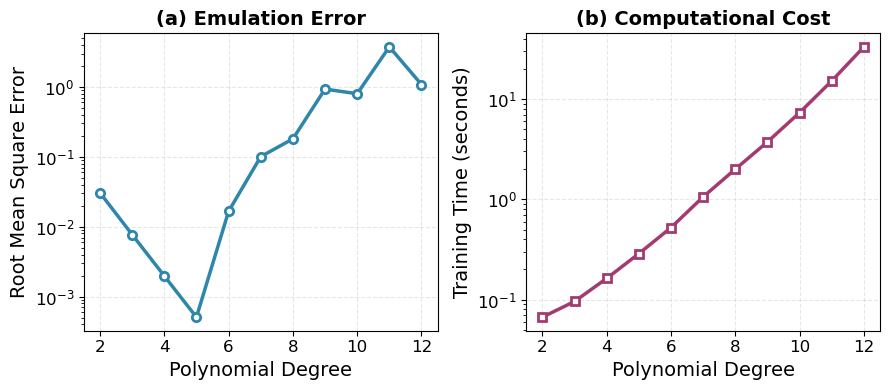

Saved publication-ready plots:
  • ../figures/polycamb_performance.pdf
  • ../figures/polycamb_performance.png


In [31]:
import matplotlib.pyplot as plt
import numpy as np

# Set up the figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 4))

# Get the data
fw_deg_li = PolyCAMB_Dl_TT.forward_degree_list
fw_RMSE_li = PolyCAMB_Dl_TT.forward_RMSE_list
fw_time_li = PolyCAMB_Dl_TT.forward_running_time_list

# Left panel: RMSE vs Polynomial Degree
ax1.plot(fw_deg_li, fw_RMSE_li, 'o-', color='#2E86AB', linewidth=2.5, 
         markersize=6, markerfacecolor='white', markeredgewidth=2, 
         markeredgecolor='#2E86AB', label='TT power spectrum')
ax1.set_yscale('log')
ax1.set_xlabel('Polynomial Degree', fontsize=14)
ax1.set_ylabel('Root Mean Square Error', fontsize=14)
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.tick_params(axis='both', which='major', labelsize=12)
ax1.set_title('(a) Emulation Error', fontsize=14, fontweight='bold')

# # Add target accuracy line
# ax1.axhline(y=0.0001, color='red', linestyle='--', alpha=0.7, 
#            label='Target RMSE = 10⁻⁴')
# ax1.legend(fontsize=11, frameon=True, fancybox=True, shadow=True)

# Right panel: Training Time vs Polynomial Degree
ax2.plot(fw_deg_li, fw_time_li, 's-', color='#A23B72', linewidth=2.5, 
         markersize=6, markerfacecolor='white', markeredgewidth=2, 
         markeredgecolor='#A23B72')
ax2.set_yscale('log')
ax2.set_xlabel('Polynomial Degree', fontsize=14)
ax2.set_ylabel('Training Time (seconds)', fontsize=14)
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.tick_params(axis='both', which='major', labelsize=12)
ax2.set_title('(b) Computational Cost', fontsize=14, fontweight='bold')

# Improve layout
plt.tight_layout()

# Add overall figure title
# fig.suptitle('PolyCAMB Emulator Performance vs Polynomial Degree', 
            #  fontsize=16, fontweight='bold', y=1.03)

# Save with high quality
plt.savefig('../figures/polycamb_performance.pdf', dpi=300, bbox_inches='tight', 
            facecolor='white', edgecolor='none')
plt.savefig('../figures/polycamb_performance.png', dpi=300, bbox_inches='tight', 
            facecolor='white', edgecolor='none')

plt.show()

print("Saved publication-ready plots:")
print("  • ../figures/polycamb_performance.pdf")
print("  • ../figures/polycamb_performance.png")

In [54]:
samples_polycamb = tail_samples(root_polycamb, keep=200_000)
samples_camb     = tail_samples(root_camb, keep=200_000)

../chains/planck_polycamb_pol.1.txt
../chains/planck_polycamb_pol.2.txt
../chains/planck_polycamb_pol.3.txt
../chains/planck_polycamb_pol.4.txt
../chains/planck_polycamb_pol.5.txt
../chains/planck_polycamb_pol.6.txt
../chains/planck_polycamb_pol.7.txt
../chains/planck_polycamb_pol.8.txt
Removed no burn in
Loaded 281211 samples from ../chains/planck_polycamb_pol
../chains/planck_polycamb_pol.1.txt
../chains/planck_polycamb_pol.2.txt
../chains/planck_polycamb_pol.3.txt
../chains/planck_polycamb_pol.4.txt
../chains/planck_polycamb_pol.5.txt
../chains/planck_polycamb_pol.6.txt
../chains/planck_polycamb_pol.7.txt
../chains/planck_polycamb_pol.8.txt
Removed 0.2887902678060247 as burn in
../chains/planck_camb_pol.1.txt
../chains/planck_camb_pol.2.txt
../chains/planck_camb_pol.3.txt
../chains/planck_camb_pol.4.txt
../chains/planck_camb_pol.5.txt
../chains/planck_camb_pol.6.txt
../chains/planck_camb_pol.7.txt
../chains/planck_camb_pol.8.txt
Removed no burn in
Loaded 244847 samples from ../chain

In [55]:
# Enhanced parameter comparison with sigma quantification
def quantify_parameter_shifts(samples_polycamb, samples_camb):
    """Quantify parameter shifts between PolyCAMB and CAMB in sigma units."""
    param_names = ["omega_b", "omega_c", "theta_star", "logA", "ns", "tau"]
    
    print("Parameter Shift Analysis:")
    print("=" * 60)
    
    shifts = {}
    for param in param_names:
        try:
            # Get marginal statistics
            poly_stats = samples_polycamb.getMargeStats().parWithName(param)
            camb_stats = samples_camb.getMargeStats().parWithName(param)
            
            # Calculate shift in sigma units
            combined_error = np.sqrt(poly_stats.err**2 + camb_stats.err**2)
            sigma_shift = abs(poly_stats.mean - camb_stats.mean) / combined_error
            
            shifts[param] = {
                'poly_mean': poly_stats.mean,
                'camb_mean': camb_stats.mean,
                'poly_err': poly_stats.err,
                'camb_err': camb_stats.err,
                'sigma_shift': sigma_shift
            }
            
            print(f"{param}:")
            print(f"  PolyCAMB: {poly_stats.mean:.5f} ± {poly_stats.err:.5f}")
            print(f"  CAMB:     {camb_stats.mean:.5f} ± {camb_stats.err:.5f}")
            print(f"  Shift:    {sigma_shift:.2f}σ")
            
            if sigma_shift < 0.5:
                print(f"  Status:   ✅ Excellent agreement")
            elif sigma_shift < 1.0:
                print(f"  Status:   ✅ Good agreement") 
            elif sigma_shift < 2.0:
                print(f"  Status:   ⚠️  Moderate difference")
            else:
                print(f"  Status:   ⚠️  Significant difference")
            print()
            
        except Exception as e:
            print(f"Error with {param}: {e}")
    
    return shifts

# Run the analysis
shifts = quantify_parameter_shifts(samples_polycamb, samples_camb)

Parameter Shift Analysis:
omega_b:
  PolyCAMB: 0.02259 ± 0.00015
  CAMB:     0.02259 ± 0.00015
  Shift:    0.01σ
  Status:   ✅ Excellent agreement

omega_c:
  PolyCAMB: 0.12149 ± 0.00139
  CAMB:     0.12150 ± 0.00137
  Shift:    0.01σ
  Status:   ✅ Excellent agreement

theta_star:
  PolyCAMB: 0.01039 ± 0.00000
  CAMB:     0.01039 ± 0.00000
  Shift:    0.01σ
  Status:   ✅ Excellent agreement

logA:
  PolyCAMB: 3.11718 ± 0.01956
  CAMB:     3.11693 ± 0.01990
  Shift:    0.01σ
  Status:   ✅ Excellent agreement

ns:
  PolyCAMB: 0.95202 ± 0.00446
  CAMB:     0.95194 ± 0.00444
  Shift:    0.01σ
  Status:   ✅ Excellent agreement

tau:
  PolyCAMB: 0.08397 ± 0.00994
  CAMB:     0.08386 ± 0.01008
  Shift:    0.01σ
  Status:   ✅ Excellent agreement



In [51]:
import pandas as pd

def min_chi2_CMB(file):
    # Read the file
    df = pd.read_csv(file, 
                     delim_whitespace=True,  # Use whitespace as delimiter
                     header=None,# skiprows=1,
                     comment='#')           # Ignore comment lines starting with #
    result = df[29].array.min()
    print(f"Minimum chi-square in {file}: {result}")
    return result

In [52]:
import numpy as np
import glob
import pandas as pd

# Collect all chain files (they are usually numbered 1–8)
files = sorted(glob.glob("../chains/planck_camb_*.txt"))  # adjust path as needed

for file in files:
    min_chi2_CMB(file)

/var/folders/r5/jq1d5z7917582lhx9y8r4rj80000gn/T/ipykernel_7406/1581874315.py:5: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file,
/var/folders/r5/jq1d5z7917582lhx9y8r4rj80000gn/T/ipykernel_7406/1581874315.py:5: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file,
/var/folders/r5/jq1d5z7917582lhx9y8r4rj80000gn/T/ipykernel_7406/1581874315.py:5: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file,


Minimum chi-square in ../chains/planck_camb_pol.1.txt: 2800.6253
Minimum chi-square in ../chains/planck_camb_pol.2.txt: 2801.8829
Minimum chi-square in ../chains/planck_camb_pol.3.txt: 2799.6363


/var/folders/r5/jq1d5z7917582lhx9y8r4rj80000gn/T/ipykernel_7406/1581874315.py:5: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file,
/var/folders/r5/jq1d5z7917582lhx9y8r4rj80000gn/T/ipykernel_7406/1581874315.py:5: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file,
/var/folders/r5/jq1d5z7917582lhx9y8r4rj80000gn/T/ipykernel_7406/1581874315.py:5: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file,


Minimum chi-square in ../chains/planck_camb_pol.4.txt: 2800.7356
Minimum chi-square in ../chains/planck_camb_pol.5.txt: 2801.8706
Minimum chi-square in ../chains/planck_camb_pol.6.txt: 2800.3759
Minimum chi-square in ../chains/planck_camb_pol.7.txt: 2802.0269
Minimum chi-square in ../chains/planck_camb_pol.8.txt: 2802.1244


/var/folders/r5/jq1d5z7917582lhx9y8r4rj80000gn/T/ipykernel_7406/1581874315.py:5: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file,
/var/folders/r5/jq1d5z7917582lhx9y8r4rj80000gn/T/ipykernel_7406/1581874315.py:5: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file,


In [53]:
# Collect all chain files (they are usually numbered 1–8)
files = sorted(glob.glob("../chains/planck_polycamb_*.txt"))  # adjust path as needed

for file in files:
    min_chi2_CMB(file)

/var/folders/r5/jq1d5z7917582lhx9y8r4rj80000gn/T/ipykernel_7406/1581874315.py:5: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file,
/var/folders/r5/jq1d5z7917582lhx9y8r4rj80000gn/T/ipykernel_7406/1581874315.py:5: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file,
/var/folders/r5/jq1d5z7917582lhx9y8r4rj80000gn/T/ipykernel_7406/1581874315.py:5: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file,


Minimum chi-square in ../chains/planck_polycamb_pol.1.txt: 2800.6322
Minimum chi-square in ../chains/planck_polycamb_pol.2.txt: 2801.5366
Minimum chi-square in ../chains/planck_polycamb_pol.3.txt: 2801.0091


/var/folders/r5/jq1d5z7917582lhx9y8r4rj80000gn/T/ipykernel_7406/1581874315.py:5: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file,
/var/folders/r5/jq1d5z7917582lhx9y8r4rj80000gn/T/ipykernel_7406/1581874315.py:5: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file,
/var/folders/r5/jq1d5z7917582lhx9y8r4rj80000gn/T/ipykernel_7406/1581874315.py:5: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file,


Minimum chi-square in ../chains/planck_polycamb_pol.4.txt: 2799.8441
Minimum chi-square in ../chains/planck_polycamb_pol.5.txt: 2802.0667
Minimum chi-square in ../chains/planck_polycamb_pol.6.txt: 2800.4552
Minimum chi-square in ../chains/planck_polycamb_pol.7.txt: 2801.3171
Minimum chi-square in ../chains/planck_polycamb_pol.8.txt: 2800.8683


/var/folders/r5/jq1d5z7917582lhx9y8r4rj80000gn/T/ipykernel_7406/1581874315.py:5: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file,
/var/folders/r5/jq1d5z7917582lhx9y8r4rj80000gn/T/ipykernel_7406/1581874315.py:5: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file,


In [2]:
from cobaya.model import get_model
from cobaya.yaml import yaml_load_file

cfg = yaml_load_file("../cobaya_test/planck_camb_bestfit.yaml")
model = get_model(cfg)

theta = {
  # cosmology
  "omega_b": 0.02237, "omega_c": 0.1200, "theta_star": 1.041,
  "tau": 0.0544, "ns": 0.965, "logA": 3.044,
  "A_planck": 1.0
}

loglikes = model.loglikes(theta)      # list per likelihood block
loglike_tot = sum(loglikes)           # total log-likelihood
chi2 = -2.0 * loglike_tot

print("logL =", loglike_tot, " chi2 =", chi2)
for name,ll in zip(model.likelihood, loglikes):
    print(name, ":", -2*ll)

[planck_2018_highl_plik.ttteee_lite] `clik` module loaded successfully from /Users/zzhang/Workspace/cobaya_packages/code/planck/clik-main/lib/python/site-packages/clik
 Initializing Planck likelihood, version Plik_v22_cmbonly_like                                                                                                                                                                                                                                                                                                                                                                                                                                                                                               
----
clik version clik_16.0b1-12-gcde855c6debd
  plik_cmbonly
Checking likelihood '/Users/zzhang/Workspace/cobaya_packages/data/planck_2018/baseline/plc_3.0/hi_l/plik_lite/plik_lite_v22_TTTEEE.clik' on test data. got -290.47 expected -292.286 (diff -1.81648)
----
logL = [nan nan nan]  chi2